# 데이터 전처리 (Data Preprocessing)

> 분석이나 머신러닝 사용하기 전, 데이터를 깨긋하게 처리하는 모든 작업

## Why?

현실 세계 에서 수집된 데이터는 거의 항상 더럽다. 예를 들면 시스템 오류도 같은 데이터가 두 번 이상 처리 되거나 휴먼에러가 발생하기 때문.

In [1]:
# 데이터 처리용 라이브러리
import pandas as pd
# 시각화 라이브러리
import matplotlib.pyplot as plt

In [2]:
# 더러운 데이터

raw_df = pd.DataFrame({
    'name' : ['kim', 'Lee', 'Park', 'Choi', 'Choi', 'Jung', 'Han', 'Oh', ],
    'study_hours' : [2, 4, None, 6, 6, 100, 5, 8],
    'attendance' : [60, 75, 80, None, None, 90, 95, 70],
    'score' : [62, 78, 82, 85, 85, None, 74, 66]

})

raw_df

,name,study_hours,attendance,score
0,kim,2.0,60.0,62.0
1,Lee,4.0,75.0,78.0
2,Park,NaN,80.0,82.0
3,Choi,6.0,NaN,85.0
4,Choi,6.0,NaN,85.0
5,Jung,100.0,90.0,NaN
6,Han,5.0,95.0,74.0
7,Oh,8.0,70.0,66.0


In [3]:
# 셀 단위로 NaN 인지 여부를 True/False로 표시
raw_df.isna()

,name,study_hours,attendance,score
0,False,False,False,False
1,False,False,False,False
2,False,True,False,False
3,False,False,True,False
4,False,False,True,False
5,False,False,False,True
6,False,False,False,False
7,False,False,False,False


In [4]:
raw_df.isna().sum()

name           0
study_hours    1
attendance     2
score          1
dtype: int64

## 결측값 처리 : 평균값으로 채우기

> "평균값 채우기" 는 정답이 아니라 시작점을 의미한다. 0, 중앙값(50%), 직전 값, 모델 예측값을 사용한다.

In [5]:
# 원본 보존 
filled_df = raw_df.copy()

filled_df['study_hours'] = filled_df['study_hours'].fillna(filled_df['study_hours'].mean())
filled_df['attendance'] = filled_df['attendance'].fillna(filled_df['attendance'].mean())
filled_df['score'] = filled_df['score'].fillna(filled_df['score'].mean())

filled_df

,name,study_hours,attendance,score
0,kim,2.000000,60.000000,62.0
1,Lee,4.000000,75.000000,78.0
2,Park,18.714286,80.000000,82.0
3,Choi,6.000000,78.333333,85.0
4,Choi,6.000000,78.333333,85.0
5,Jung,100.000000,90.000000,76.0
6,Han,5.000000,95.000000,74.0
7,Oh,8.000000,70.000000,66.0


## 결측값 처리 : 결측값이 있는 행 제거하기

**when?**
- 결측 비율이 낮을 때(예: 전체 1~5% 이하)
- 그 행을 잃어도 분석 결과에 큰 영향이 없을 때
- 조금이라도 비어 있는 데이터를 신뢰하지 않을 때 (보수적 정책)

In [6]:
# 'dropped()' 는 결측값이 하나라도 있는 행을 통째로 삭제하는 함수

dropped_df = raw_df.dropna()
dropped_df

,name,study_hours,attendance,score
0,kim,2.0,60.0,62.0
1,Lee,4.0,75.0,78.0
6,Han,5.0,95.0,74.0
7,Oh,8.0,70.0,66.0


## 중복 데이터 제거하기

같은 행이 두 번 들어가 있으면, 한 사람이 두명처럼 카운트되어 평균/합계/비율 같은 집계가 모두 왜곡이 된다.

In [7]:
filled_df.duplicated()


0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
dtype: bool

In [8]:
no_duplicated_df = filled_df.drop_duplicates()
no_duplicated_df

,name,study_hours,attendance,score
0,kim,2.000000,60.000000,62.0
1,Lee,4.000000,75.000000,78.0
2,Park,18.714286,80.000000,82.0
3,Choi,6.000000,78.333333,85.0
5,Jung,100.000000,90.000000,76.0
6,Han,5.000000,95.000000,74.0
7,Oh,8.000000,70.000000,66.0


## 문자열 공백 제거하기
"kim" == " kim" -> False

In [9]:
clean_name_df = no_duplicated_df.copy()
clean_name_df['name'] = clean_name_df['name'].str.strip()
clean_name_df

# Series.str.strip() - 압뒤 공백 제거
# Series.str.lstrip() - 압 공백 제거
# Series.str.rstrip() - 뒤 공백 제거
# Series.str.replace(" ", "") - 모든 공백 제거
# .str.strip() 거는 습관이 필요

,name,study_hours,attendance,score
0,kim,2.000000,60.000000,62.0
1,Lee,4.000000,75.000000,78.0
2,Park,18.714286,80.000000,82.0
3,Choi,6.000000,78.333333,85.0
5,Jung,100.000000,90.000000,76.0
6,Han,5.000000,95.000000,74.0
7,Oh,8.000000,70.000000,66.0


## 이상치(outlier) 확인하기
> 다른 값들과 비교했을 때, 지나치게 크거나 작은 값

1. 입력 오류/측정 오류 - 단위를 잘못 적었거나 센서가 튄 경우 -> 제거/수정하는 것이 옳다.
2. 특이한 사례 - 압도적으로 점수가 높거나/낮거나, 고액 결제

In [10]:
clean_name_df.describe()

,study_hours,attendance,score
count,7.000000,7.000000,7.000000
mean,20.530612,78.333333,74.714286
std,35.460500,11.785113,8.260635
min,2.000000,60.000000,62.000000
25%,4.500000,72.500000,70.000000
50%,6.000000,78.333333,76.000000
75%,13.357143,85.000000,80.000000
max,100.000000,95.000000,85.000000


<function matplotlib.pyplot.show(close=None, block=None)>

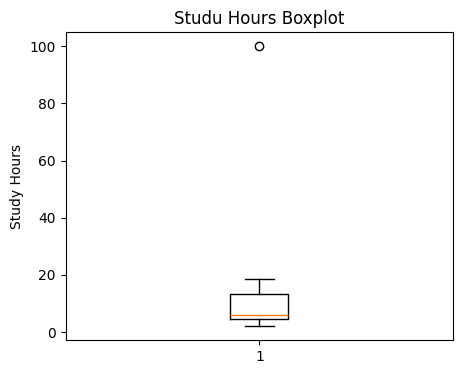

In [11]:
plt.figure(figsize=(5,4))
plt.boxplot(clean_name_df['study_hours'])
plt.title('Studu Hours Boxplot')
plt.ylabel('Study Hours')
plt.show

# IQR 로 이상치 제거하기
> IQR(Interquartile Range): 데이터를 정렬했을 때, 거윤대 50% 가 차지하는 범위

**계산 절차**
1. Q1 = 하위 25% 지점의 값
2. Q3 = 상위 25% 지점의 값 (=하위75%)
3. IQR = Q3 - Q1 (가운데 50%의 폭)
4. 정상 범위 = [Q1 - 1.5 x IQR, Q3 + 1.5 x IQR]
5. 이 범위를 벗어나면 이상치로 간주

**왜 1.5를 사용하느가?**
정규분포에서 위 범위 바깥에 떨어질 확률이 약 0.7% 로 매우 낮기 때문에, 통계 학자 John Tukey 가 BoxPlot 을 만들면서 제안한 경험적 기준

- 1.5 -> 일반적으로 쓰는 기준
- 3.0 -> 보수적인 기준 (극단적인 값만 골라냄)

In [12]:
# .quantile(): 사분위수
q1 = clean_name_df['study_hours'].quantile(0.25)
q3 = clean_name_df['study_hours'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)
print('정상범위:', lower, '~', upper)

Q1: 4.5
Q3: 13.357142857142858
IQR: 8.857142857142858
정상범위: -8.785714285714286 ~ 26.642857142857146


In [15]:
clean_df = clean_name_df[
    (clean_name_df['study_hours'] >= lower) &
    (clean_name_df['study_hours'] <= upper) 
]
clean_df

,name,study_hours,attendance,score
0,kim,2.000000,60.000000,62.0
1,Lee,4.000000,75.000000,78.0
2,Park,18.714286,80.000000,82.0
3,Choi,6.000000,78.333333,85.0
6,Han,5.000000,95.000000,74.0
7,Oh,8.000000,70.000000,66.0


## 전처리 후 새 열 만들기
데이터를 깨긋이 정리한 뒤에야 의미 있는 분석이 가능하다.
점수(score) 가 75점 기준으로 합격/불합격을 표시하는 pass_fail 열을 추가하기

In [16]:
final_df = clean_df.copy()
final_df['pass_fail'] = final_df['score'].apply(lambda x: 1 if x >= 75 else 0)
final_df

,name,study_hours,attendance,score,pass_fail
0,kim,2.000000,60.000000,62.0,0
1,Lee,4.000000,75.000000,78.0,1
2,Park,18.714286,80.000000,82.0,1
3,Choi,6.000000,78.333333,85.0,1
6,Han,5.000000,95.000000,74.0,0
7,Oh,8.000000,70.000000,66.0,0


**문제**
아래의 데이터를 전처리하시오.

실습용 매출 데이터
- product : 앞뒤 공백 섞임
- price : 결측값이 2개
- quantity: 결측값이 1개

```python
sales_raw = pd.DataFrame({
'product' : [" Apple", "Banana ", "Orange", "Orange", "Milk", "Bread"]
'price' : [ 1200, 800, None, None, 1650, 2000]
'quantity': [ 5, 3, 4, 4, None, 2]
})
```